Monte Carlo Wigner Method Demo:

In this notebook, we introduce the Monte Carlo Wigner (MCW) method. For the first part, I’m going to compare it to a standard split-step Fourier (SSF) solution of the time-dependent Schrödinger equation in 1D.
In the second part, we’ll demonstrate how signed-particle branching reproduces tunneling dynamics in anharmonic potentials.
In the last part, it will be introduced to classical wave propagation.

## Part 1: 1D Gaussian Wave Packet in a Harmonic Potential
In the first part, we will:
    Construct an initial Gaussian wave packet in position space.
    Propagate it using the split-step Fourier method in a harmonic potential(Schrodinger’s result).
    Sample the corresponding Wigner function using Monte Carlo (Gaussian sampling in (x,p)).
    Propagate the Monte Carlo “signed particles” along classical trajectories in the harmonic potential.
    Reconstruct the position density from MCW and compare it to Schrodinger’s result at different times.

To start, we import numpy and matplotlib.pyplot since we want to genearte (random) numbers and plot and compare the results.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Setup figure and font size
#plt.rcParams["figure.figsize"] = (6, 4)
#plt.rcParams["font.size"] = 12


Step 1: Define a Gaussian wave packet

We first define a normalized Gaussian wave packet in position space.
Instead of directly constructing a fixed grid wavefunction, we write a function that takes an array of positions
x and returns ψ(x).

This will be especially helpful the later Monte Carlo step, where we can sample random x-values from the same Gaussian distribution if we make a definition instead of making an array here.

In [2]:
def gaussian_wavepacket(x, x0=0.0, p0=0.0, sigma=1.0, hbar=1.0):
    """
    Construct a normalized Gaussian wave packet in 1D.

    Parameters
    ----------
    x : array
        Position grid.
    x0 : float
        Initial central position.
    p0 : float
        Initial central momentum.
    sigma : float
        Width (standard deviation) in position.
    hbar : float
        Reduced Planck's constant.

    Returns
    -------
    psi : complex array
        Complex-valued wavefunction psi(x).
    """
    norm = (1.0 / (np.pi * sigma**2))**0.25
    phase = 1j * p0 * (x - x0) / hbar
    envelope = np.exp(-(x - x0)**2 / (2 * sigma**2))
    return norm * envelope * np.exp(phase)


Step 2: Split-step Fourier propagation (Schrödinger evolution)

Next, we implement a split-operator propagator for the 1D Schrödinger equation in a potential V(x).
We split the Hamiltonian into kinetic and potential parts:
The potential part is diagonal in x-space.
The kinetic part is diagonal in k-space (after Fourier transform).
Each small time step Δt is approximated using the usual symmetric (Strang) splitting:

“half potential → full kinetic → half potential.”

The reason for using this Strang splitting is that, compare to doing whole potential and kinetic steps, this will reduce its error to a 2nd order according to Baker-Campbell-Hausdorff formula.

In [3]:
def split_operator_propagate(psi0, x, dt, nsteps, V_func, m=1.0, hbar=1.0):
    """Time-evolve a 1D wavefunction using the split-step Fourier method.

    Parameters
    ----------
    psi0 : complex array
        Initial wavefunction psi(x, t=0).
    x : array
        Position grid (uniformly spaced).
    dt : float
        Time step.
    nsteps : int
        Number of time steps.
    V_func : callable
        Function V(x) returning the potential evaluated on the grid.
    m : float
        Mass parameter in the Schrödinger equation.
    hbar : float
        Reduced Planck's constant.

    Returns
    -------
    psi_t : array, shape (nsteps+1, Nx)
        Time sequence of wavefunctions psi(x, t_n), with t_n = n * dt.
    """
    # Ensure complex dtype
    psi = np.asarray(psi0, dtype=complex).copy()

    # Grid and Fourier variables
    N = x.size
    dx = x[1] - x[0]
    k = 2.0 * np.pi * np.fft.fftfreq(N, d=dx)

    # Potential and propagators
    Vx = V_func(x)
    U_V_half = np.exp(-1j * Vx * dt / (2.0 * hbar))
    U_T = np.exp(-1j * (hbar * k**2 / (2.0 * m)) * dt)

    psi_t = [psi.copy()]

    for _ in range(nsteps):
        # Half potential step
        psi *= U_V_half

        # Full kinetic step in Fourier domain
        psi_k = np.fft.fft(psi)
        psi_k *= U_T
        psi = np.fft.ifft(psi_k)

        # Final half potential step
        psi *= U_V_half

        # Renormalize to avoid accumulation of numerical error
        prob = np.trapz(np.abs(psi)**2, x)
        if prob > 0:
            psi /= np.sqrt(prob)

        psi_t.append(psi.copy())

    return np.array(psi_t)


Step 3: Sampling the Wigner function for a Gaussian state

The Wigner function for a Gaussian wave packet is itself Gaussian in both x and p.
To build a Monte Carlo Wigner representation, we sample a large number of “phase-space points” (x,p) from this Gaussian distribution.
For a pure Gaussian state, the Wigner function is positive everywhere, so the signs of the “Wigner particles” are all +1. In Monte Carlo Wigner simulation, we do a trick to simplify the Wigner function to a discrete sum, called signed particle representation, to further simplify propagation.

To restate the general idea behind MCW propagation, the overall dynamic-quantum Wigner function, or Wigner-Moyal equation has a complicated infinite quantum correction term, and we use a branching method to replace that, therefore we have a classical differential Wigner function with an extra quantum correction "branching" term. Before considering the complicated branching term, we first simplify the dynamical Wigner function to a signed particle representation in the equation:
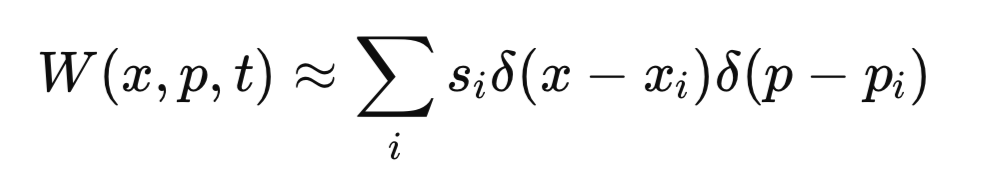
Which is a summation of particles' (which we know their x and p) signs. So we first need to define sampling that randomly selects x and p with signs.

To note that, this representation only includes x and p, so we only need to evolve (x,p) classically with dx/dt = p/m and dp/dt = - dV/dx, and sum all final particles.

Also in part 1, we don't consider the quantum branching coefficient term, but we still use the signed-particle representation.

In [4]:
def sample_wigner_gaussian(Np, x0=0.0, p0=0.0, sigma=1.0, hbar=1.0, seed=None):
    """
    Sample (x, p, sign) points from the Wigner function of a Gaussian state.

    For a minimum-uncertainty Gaussian, the Wigner function factorizes into
    Gaussians in x and p, so we can sample x and p independently from normal
    distributions.

    Parameters
    ----------
    Np : int
        Number of phase-space sample points.
    x0 : float
        Central position of the packet.
    p0 : float
        Central momentum of the packet.
    sigma : float
        Width in position.
    hbar : float
        Reduced Planck's constant.
    seed : int or None
        Random seed for reproducibility.

    Returns
    -------
    xs : array
        Sampled positions.
    ps : array
        Sampled momenta.
    signs : int array
        Signs associated with each sample (+1 here).
    """
    rng = np.random.default_rng(seed)

    xs = x0 + sigma * rng.standard_normal(Np)
    ps = p0 + (hbar / sigma) * rng.standard_normal(Np)
    signs = np.ones(Np, dtype=int)

    return xs, ps, signs


Step 4: Monte Carlo Wigner propagation in a harmonic potential

To evolve the sampled phase-space points, we use the classical equations of motion for a harmonic oscillator.
For a harmonic potential V(x)= 1/2mω^2*x^2, the classical trajectories in phase space follow elliptical orbits. Here we implement a simple symplectic (leapfrog) integrator to propagate (x,p) forward in discrete time steps.

In [5]:
def mcw_propagate_harmonic(xs, ps, signs, dt, nsteps, m=1.0, omega=1.0):
    """
    Propagate phase-space samples (xs, ps) for a harmonic oscillator using
    a simple symplectic (leapfrog) scheme.

    Parameters
    ----------
    xs, ps : arrays
        Initial positions and momenta of the Wigner samples.
    signs : int array
        Signs of the samples (carried along unchanged here).
    dt : float
        Time step.
    nsteps : int
        Number of time steps.
    m : float
        Mass.
    omega : float
        Harmonic oscillator frequency.

    Returns
    -------
    traj_x : array, shape (nsteps, Np)
        x-coordinates of all samples as a function of time.
    traj_p : array, shape (nsteps, Np)
        p-coordinates of all samples as a function of time.
    signs : int array
        Returned unchanged.
    """
    x = xs.copy()
    p = ps.copy()
    traj_x = []
    traj_p = []

    for _ in range(nsteps):
        # Half-step momentum update
        p_half = p - 0.5 * dt * m * omega**2 * x
        # Full-step position update
        x_new = x + dt * p_half / m
        # Half-step momentum update with new x
        p_new = p_half - 0.5 * dt * m * omega**2 * x_new

        x, p = x_new, p_new
        traj_x.append(x.copy())
        traj_p.append(p.copy())

    return np.array(traj_x), np.array(traj_p), signs


Step 5: Reconstructing the position density from MCW samples(2D to 1D conversion)

To compare the Monte Carlo Wigner result with the quantum probability density ∣ψ(x,t)|^2
 , we must reconstruct a continuous position-space density from discrete phase-space samples.
The MCW method produces signed particles whose positions represent a Monte Carlo sampling of the Wigner marginal ρ(x)=∫W(x,p)dp in a weak sense. Therefore, the raw output corresponds to a sum of weighted delta functions rather than a smooth function. We apply kernel density estimation (KDE) to reconstruct a smooth position-space marginal. KDE is a post-processing step and does not affect the underlying MCW dynamics.

We therefore use a narrow Gaussian kernel density estimator to regularize the Monte Carlo samples and obtain a continuous approximation of ρ(x). This smoothing does not approximate numerical integration on a grid; instead, it mitigates sampling noise inherent to Monte Carlo methods. The kernel width is chosen small enough to minimize bias while maintaining numerical stability.

The resulting density is normalized after reconstruction, with a small numerical offset 10^-15 added to the normalization denominator to prevent division of 0.

In [6]:
def wigner_to_position_density(xs, signs, x_grid, bandwidth=0.25):
    """
    Approximate the position probability density from MCW samples.

    Parameters
    ----------
    xs : array
        Sampled positions at a fixed time.
    signs : int array
        Signs for each sample (+1 for a pure Gaussian case).
    x_grid : array
        Grid on which to evaluate the density.
    bandwidth : float
        Width of the Gaussian kernel used for smoothing.

    Returns
    -------
    rho : array
        Approximate, normalized position probability density on x_grid.
    """
    dx = x_grid[1] - x_grid[0]
    rho = np.zeros_like(x_grid, dtype=float)

    inv_two_bw2 = 1.0 / (2 * bandwidth**2)
    for x0, s in zip(xs, signs):
        rho += s * np.exp(-(x_grid - x0)**2 * inv_two_bw2)

    # Normalize kernel contributions
    rho *= dx / (np.sqrt(2 * np.pi) * bandwidth * len(xs))

    # Remove tiny negative values from numerical noise
    rho[rho < 0] = 0.0

    # Final normalization to ensure ∫ rho dx ≈ 1
    norm = rho.sum() * dx + 1e-15
    rho /= norm

    return rho


Step 6: Full part 1 and comparison

Finally, we can put everything together from everything defined above:

Define physical parameters and the harmonic potential.
Construct the spatial grid and initial wave packet.
Propagate the wavefunction using split-step Fourier (Schrödinger).
Sample and propagate MCW particles in phase space.
At selected times, compare ∣ψ(x,t)∣^2 to the Monte Carlo Wigner-derived density.


Optional step: Sanity Check

It'll also be nice if we have a simple check of Sanity here to see whether the propagations above is right. A simplest way to do is is to set V = 0 to see how the propagated beam looks like. If there is no potential, the Gaussian beam would look exactly the same. Uncomment the V=0 line and comment the original V in the below cell to do the sanity check.

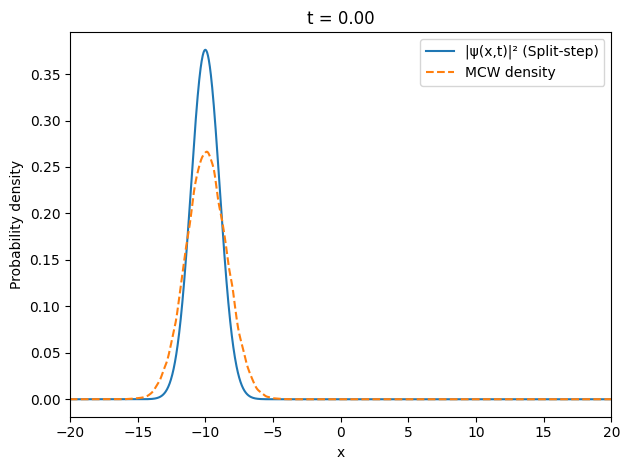

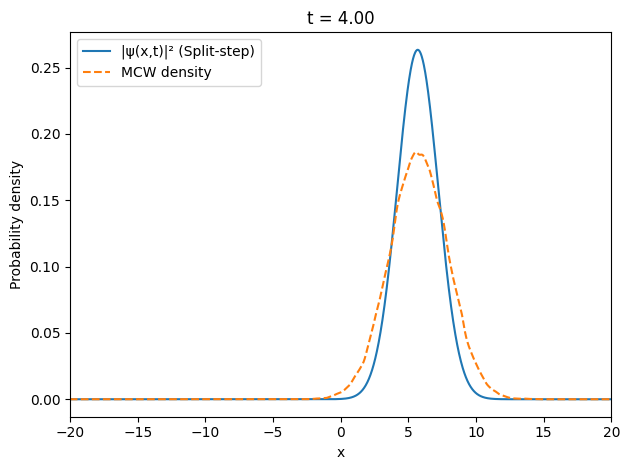

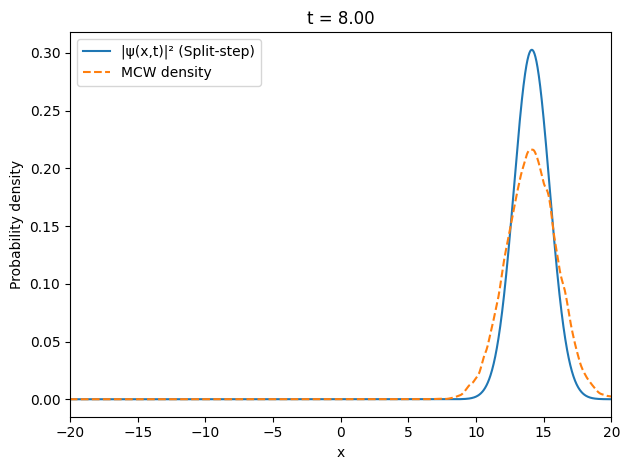

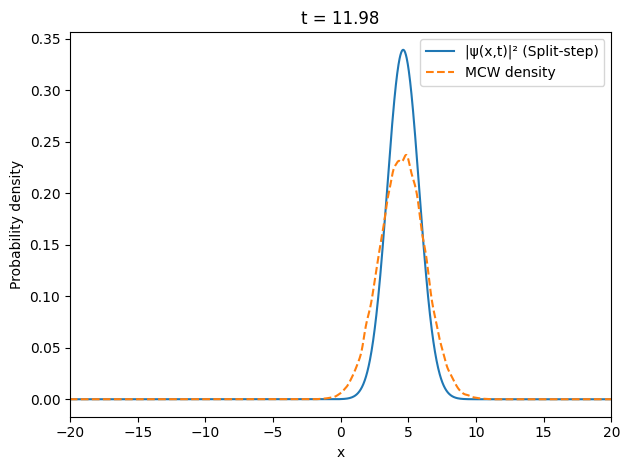

In [7]:
def demo_mcw_vs_split_step():
    # Physical parameters
    hbar = 1.0
    m = 1.0
    omega = 0.3

    # Harmonic potential
    V = lambda x: 0.5 * m * omega**2 * x**2
    ## Sanity Check
    #V = lambda x: 0.0 * m * omega**2 * x**2

    # Spatial grid
    N = 2**12
    x_max = 40.0
    x = np.linspace(-x_max, x_max, N, endpoint=False)

    # Initial Gaussian wave packet parameters
    x0 = -10.0
    p0 = 3.0
    sigma = 1.5
    psi0 = gaussian_wavepacket(x, x0=x0, p0=p0, sigma=sigma, hbar=hbar)

    # Time grid
    dt = 0.02
    T = 12.0
    nsteps = int(T / dt)

    # Quantum (split-step) propagation
    psi_t = split_operator_propagate(psi0, x, dt, nsteps, V, m=m, hbar=hbar)

    # MCW: sample initial Wigner and propagate classically
    Np = 40000
    xs0, ps0, signs0 = sample_wigner_gaussian(
        Np, x0=x0, p0=p0, sigma=sigma, hbar=hbar, seed=123
    )
    traj_x, traj_p, signs = mcw_propagate_harmonic(
        xs0, ps0, signs0, dt, nsteps, m=m, omega=omega
    )

    # Times at which to compare
    times_to_plot = [0.0, 4.0, 8.0, 12.0]

    for t_target in times_to_plot:
        t_idx = min(int(t_target / dt), nsteps - 1)
        t = t_idx * dt

        psi = psi_t[t_idx]
        rho_s = np.abs(psi)**2
        dx = x[1] - x[0]
        rho_s /= (rho_s.sum() * dx)

        xs = traj_x[t_idx]
        rho_m = wigner_to_position_density(xs, signs, x, bandwidth=0.15)

        plt.figure()
        plt.plot(x, rho_s, label='|ψ(x,t)|² (Split-step)')
        plt.plot(x, rho_m, '--', label='MCW density (KDE)')
        plt.xlim(-20, 20)
        plt.xlabel('x')
        plt.ylabel('Probability density')
        plt.title(f't = {t:.2f}')
        plt.legend()
        plt.tight_layout()
        plt.show()

demo_mcw_vs_split_step()

Basically, this entire part 1 serves as a sanity check, since the only difference between part 1 and part two is that for part two we add branching (though we also assign different potentials, the function of split step fourier we use in part 2 is what we've defined in part 1 above). For part 1 we showed that without branching, MCW and Split Step Fourier yields the same result, this proves that it's workable and we can continue to add branching in the next part.

Though it's theoretically the same result, on the graph since we're normalizing MCW by the area under curve, and MCW undergoes smoothing in the definition of wigner_to_position_density(), it's having a slightly wider shape but the same area under curve, that we can still consider it to be a reasonable result comparing to the theoretical result by Split Step Fourier.

Also, since we're using the branched representation of Wigner function for the calculation, this will makes it differ from the actual result in this classical case when we don't have negative signs and branching coefficients. Here the result from SSFM serves as a ground truth for the wave function propagation, while in the following sections MCW would be the ground truth considering branching term, and SSFM will be less accurate, but still serves as a comparison only considering classical terms. MCW works most efficiently when we add branching and in higher dimensions.

## Part 2: MCW tunneling in an anharmonic (double–well) potential

In this section, we extend the Monte Carlo Wigner (MCW) method to an actual quantum case, an anharmonic potential where tunneling plays an important role. A standard example
is a symmetric double–well potential
V(x) = a (x^2 - x0^2)^2,
which has two minima at x = x_0 separated by a barrier at x = 0.

Continuing with the first part we will initialize also a Gaussian wave packet localized in the left well and propagate:

1. Using the split-step Fourier method (solving the Schrödinger equation).
2. Using a MCW scheme with "signed-particle branching".

The MCW method here is an approximate approach: we use classical equations of motion for each particle (x,p) and add a stochastic branching process, that its rate depends on the local potential. New particles are created with opposite signs and slightly shifted momenta, mimicking the nonlocal Wigner kernel and allowing tunneling-like behavior to appear in the reconstructed position density.


Step 1: So we'll first define the potential well in the next code cell, as well as its derivative dV/dx for convenience. Similar to the first part, we left the x parameter as an input for convenience; a and x0 are assigned but can be changed for different potential well settings.

In [8]:
def double_well_potential(x, a=0.01, x0=4.0):
    """
    Symmetric double-well potential:
        V(x) = a * (x^2 - x0^2)^2

    Parameters
    ----------
    x : array or float
        Position.
    a : float
        Strength of the quartic term (controls barrier height).
    x0 : float
        Location of the minima (±x0).
    """
    return a * (x**2 - x0**2)**2


def dV_double_well_dx(x, a=0.01, x0=4.0):
    """
    Derivative dV/dx of the double-well potential:
        dV/dx = 4 a x (x^2 - x0^2)
    """
    return 4.0 * a * x * (x**2 - x0**2)


Step 2: To define this potential well, we take some parameters from the first part. The new things we add here are signs and branching part. Unlike what we did in the first part, in a branching event we consider taking one particle and split it into two, that they have different signs and slightly shifted momenta dp_branch.

As we've mentioned before, we need an extra "branching coefficient" for the quantum case, while in part 1 we don't have it. The classical or deterministic part still stays the same as in part 1, so similarly we'll consider change in x and p dx/dt and dp/dt in the Wigner-Moyal equation. The extra branching coefficient we add is just a percentage that decides whether the particle will branch, whether it's quantum-like or classical-like. For example, when a particle is near regions of V=0, it will behave more classically, however, when it's near a potential well, it'll be more likely to tunnel, or to "branch".

In [9]:
def mcw_propagate_double_well(
    xs,
    ps,
    signs,
    dt,
    nsteps,
    m=1.0,
    a=0.01,
    x0=4.0,
    gamma0=0.02,
    dp_branch=0.5,
    x_max_abs=40.0,
    record=False,
):
    """
    MCW propagation in a double-well potential with a simple branching rule.

    - Deterministic part: classical equations of motion
        dx/dt = p / m
        dp/dt = - dV/dx
    - Stochastic part: branching events intended to mimic the Wigner kernel:
        With position-dependent rate gamma(x), a particle "branches" into
        two new particles with signs ±sign, same x, and slightly shifted
        momenta p ± dp_branch.

    Note: This is a pedagogical MCW implementation rather than a fully
    rigorous signed-particle Wigner solver.

    Parameters
    ----------
    xs, ps : 1D arrays
        Particle positions and momenta.
    signs : 1D array of ±1
        Particle signs (weights).
    dt : float
        Time step.
    nsteps : int
        Number of time steps.
    m : float
        Mass.
    a, x0 : float
        Double-well parameters.
    gamma0 : float
        Base branching rate; larger -> more branching events.
    dp_branch : float
        Momentum shift for new particles created in a branching event.
    x_max_abs : float
        Soft cutoff: particles with |x| > x_max_abs are discarded.

    Returns
    -------
    xs, ps, signs : arrays
        Final particle cloud.
    """
    # Optional: record particle states over time for visualization
    traj_x = []
    traj_p = []
    traj_s = []
    if record:
        traj_x.append(xs.copy())
        traj_p.append(ps.copy())
        traj_s.append(signs.copy())

    xs = np.asarray(xs, dtype=float)
    ps = np.asarray(ps, dtype=float)
    signs = np.asarray(signs, dtype=float)

    rng = np.random.default_rng()

    for _ in range(nsteps):
        # 1) Deterministic classical update (simple symplectic / leapfrog-like)
        # half kick
        accel = -dV_double_well_dx(xs, a=a, x0=x0) / m
        ps_half = ps + 0.5 * dt * accel

        # drift
        xs_new = xs + dt * ps_half / m

        # recompute acceleration at new positions
        accel_new = -dV_double_well_dx(xs_new, a=a, x0=x0) / m
        ps_new = ps_half + 0.5 * dt * accel_new

        xs, ps = xs_new, ps_new

        # Optional: remove particles that fly too far out
        mask = np.abs(xs) < x_max_abs
        xs, ps, signs = xs[mask], ps[mask], signs[mask]

        # 2) Stochastic branching
        # Use a crude measure of local anharmonicity:
        #   gamma(x) = gamma0 * max(0, |x| - x0/2)
        # so branching happens mainly near the barrier and outer regions.
        gamma_x = gamma0 * np.maximum(0.0, np.abs(xs) - 0.5 * x0)

        # For each particle, decide whether to branch this step
        # Probability ~ gamma(x) * dt (must be <= 1)
        prob_branch = gamma_x * dt
        prob_branch = np.clip(prob_branch, 0.0, 0.3)  # avoid too many branches

        random_vals = rng.random(xs.shape)
        do_branch = random_vals < prob_branch

        if np.any(do_branch):
            # Particles that branch
            xs_b = xs[do_branch]
            ps_b = ps[do_branch]
            s_b = signs[do_branch]

            # Create two new particles with ± sign and shifted momenta
            xs_new_particles = np.concatenate([xs_b, xs_b])
            ps_new_particles = np.concatenate([ps_b + dp_branch, ps_b - dp_branch])
            signs_new_particles = np.concatenate([s_b, -s_b])

            # Keep the original particles as well (or, for another variant, remove them)
            xs = np.concatenate([xs, xs_new_particles])
            ps = np.concatenate([ps, ps_new_particles])
            signs = np.concatenate([signs, signs_new_particles])
        if record:
            traj_x.append(xs.copy())
            traj_p.append(ps.copy())
            traj_s.append(signs.copy())


    return (traj_x, traj_p, traj_s) if record else (xs, ps, signs)


Step 3: Now we're prepared to put a Gaussian pulse through the potential well to see how it tunnels. As before, we use a split-step method and MCW for comparison. We use the same function in part 1 to generate a Gaussian pulse but at the left end of potential well this time.

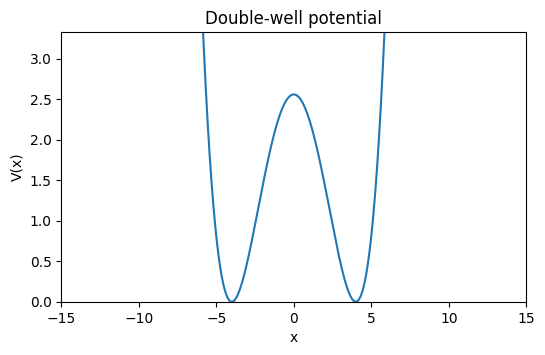

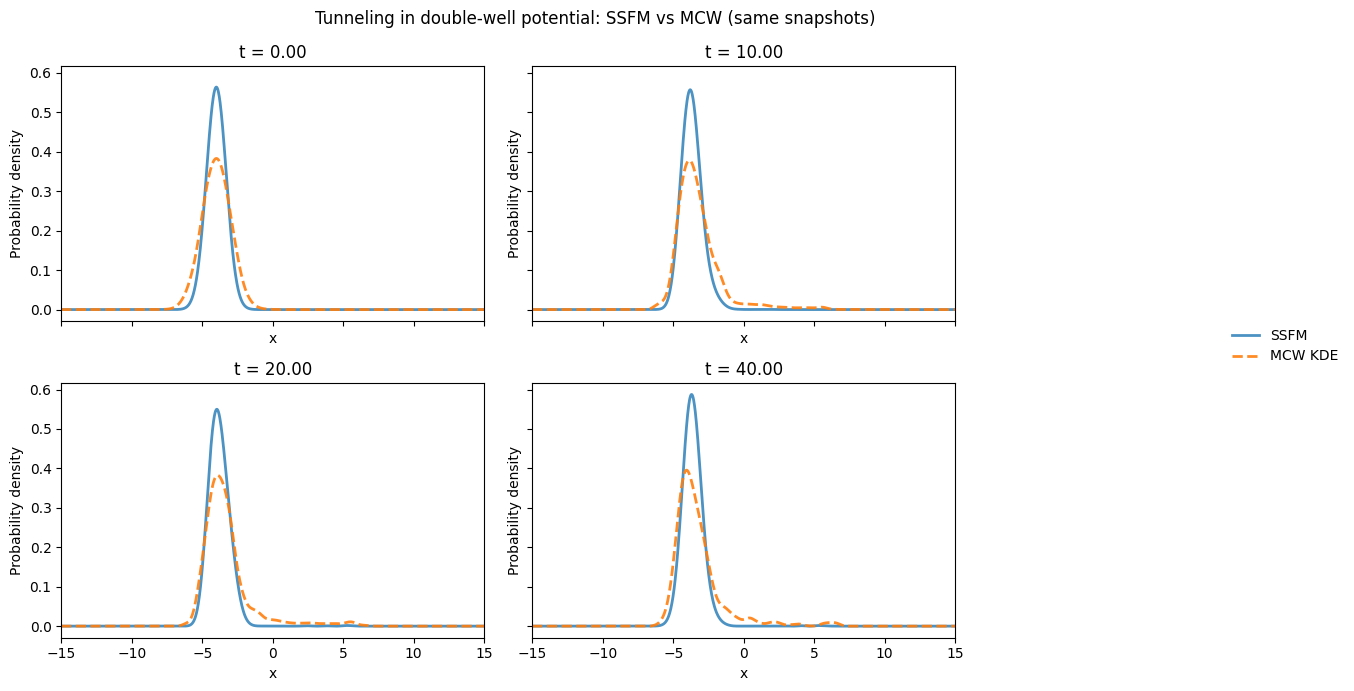

In [10]:
def demo_mcw_tunneling_double_well():
    """
    Compare Schrödinger split-step evolution and MCW (with branching)
    for a Gaussian wave packet initially localized in the left well
    of a symmetric double-well potential.
    """
    hbar = 1.0
    m = 1.0
    a = 0.01
    x0_dw = 4.0  # minima at ±x0_dw

    # Spatial grid
    N = 2**12
    x_max = 40.0
    x = np.linspace(-x_max, x_max, N, endpoint=False)

    # Plot the double-well potential before propagation
    Vx = double_well_potential(x, a=a, x0=x0_dw)

    plt.figure(figsize=(6,3.5))
    plt.plot(x, Vx)
    plt.xlabel('x')
    plt.ylabel('V(x)')
    plt.title('Double-well potential')

    # Zoom to the region where the wells live and scale y so the barrier is visible
    plt.xlim(-15, 15)
    V_barrier = double_well_potential(0.0, a=a, x0=x0_dw)  # barrier height at x=0
    plt.ylim(0, 1.3 * V_barrier)

    plt.show()

    # Initial wave packet in the left well (near -x0_dw)
    x0_init = -x0_dw
    p0_init = 0.0
    sigma_init = 1.0
    psi0 = gaussian_wavepacket(x, x0=x0_init, p0=p0_init,
                               sigma=sigma_init, hbar=hbar)

    # Time stepping (choose longer time to see tunneling)
    dt = 0.05
    nsteps = 800  # number of time steps

    # 1) Schrödinger evolution with split-step
    def V_func_dw(xgrid):
        return double_well_potential(xgrid, a=a, x0=x0_dw)

    psi_t = split_operator_propagate(psi0, x, dt, nsteps,
                                     V_func_dw, m=m, hbar=hbar)
    # psi_t has shape (N_frames, N_grid), where N_frames == nsteps or nsteps+1
    n_frames = psi_t.shape[0]

    # Choose snapshot indices safely within [0, n_frames-1]
    indices = [
        0,
        n_frames // 4,
        n_frames // 2,
        n_frames - 1
    ]
    times_to_plot = [idx * dt for idx in indices]

    # 2) MCW initial sampling (from Gaussian Wigner)
    Np = 20000
    xs, ps, signs = sample_wigner_gaussian(
        Np,
        x0=x0_init,
        p0=p0_init,
        sigma=sigma_init,
        hbar=hbar,
    )

    # 3) MCW propagation with branching in double-well
    traj_x, traj_p, traj_s = mcw_propagate_double_well(
        xs,
        ps,
        signs,
        dt,
        nsteps,
        m=m,
        a=a,
        x0=x0_dw,
        gamma0=0.02,
        dp_branch=0.7,
        x_max_abs=x_max,
        record=True,
    )

    # Reconstruct MCW marginal at final time
    rho_m_final = wigner_to_position_density(
        traj_x[-1], traj_s[-1], x, bandwidth=0.3
    )
    rho_m_final /= np.trapz(rho_m_final, x)

    # Plot frames of Schr density |ψ(x,t)|²

    # --- Combined snapshot figure: Schrödinger vs MCW at the same times ---
    # Increase particle count if you want tighter agreement / less Monte Carlo noise
    # (Np is set above; consider 20000+ for smoother MCW curves)
    bw = 0.3  # KDE bandwidth in x-units

    fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharex=True, sharey=True)
    axes = axes.ravel()

    for ax, t, idx in zip(axes, times_to_plot, indices):
        # Schrödinger density (normalized)
        psi = psi_t[idx]
        rho_s = np.abs(psi)**2
        rho_s /= np.trapz(rho_s, x)

        # MCW reconstructed density (normalized)
        rho_m = wigner_to_position_density(traj_x[idx], traj_s[idx], x, bandwidth=bw)
        rho_m /= np.trapz(rho_m, x)

        ax.plot(x, rho_s, linewidth=2.0, alpha=0.8, label='SSFM')
        ax.plot(x, rho_m, '--', linewidth=2.0, alpha=0.9, label='MCW KDE')

        ax.set_title(f"t = {t:.2f}")
        ax.set_xlim(-15, 15)
        ax.set_xlabel('x')
        ax.set_ylabel('Probability density')

    # Single legend for the whole figure
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='center left', bbox_to_anchor=(1.02, 0.5), frameon=False)
    fig.suptitle('Tunneling in double-well potential: SSFM vs MCW (same snapshots)', y=0.98)
    fig.tight_layout(rect=[0, 0, 0.82, 1])
    plt.show()

demo_mcw_tunneling_double_well()



## Part 3: MCW for classical paraxial wave propagation

In the paraxial approximation, the slowly varying envelope U(x,z) of a scalar
optical field satisfies an equation that is mathematically equivalent to the
Schrödinger equation,
i * dU/dz = -1/(2k_0) * d^2U/dx^2 + Vopt(x),

where k_0 is the wavenumber and Vopt(x) represents index variations.
If we set m = k_0 and ℏ = 1, this is isomorphic to

iℏ * d𝜓(x,t)/dt = -ℏ^2/2m * d^2𝜓(x,t)/dx^2 + V(x)𝜓(x,t)

In free space Vopt = 0, the associated Wigner function obeys a
Liouville equation and can be propagated by classical trajectories. This is a
classical limit of the MCW method:

- Sample the initial Wigner function of a Gaussian beam.
- Propagate each particle according to
  dx/dz = p/m, dp/dz = 0.
- Reconstruct the intensity by summing over the particles.

We compare this MCW–ray picture to a split-step propagation (Fresnel diffraction)
of a Gaussian field.

Step 1. Now as the first step, we define the propagation of MCW


In [11]:
def mcw_propagate_free_optics(xs, ps, dz, nsteps, m=1.0, x_max_abs=40.0):
    """
    MCW propagation for free-space paraxial optics (classical limit).

    Equations of motion:
        dx/dz = p / m
        dp/dz = 0

    Parameters
    ----------
    xs, ps : arrays
        Initial positions and transverse momenta/frequencies.
    dz : float
        Step in propagation distance z.
    nsteps : int
        Number of propagation steps.
    m : float
        "Mass" parameter, analogous to k0 in paraxial optics.
    x_max_abs : float
        Soft cutoff for discarding rays that wander too far.

    Returns
    -------
    xs, ps : arrays
        Final positions and momenta.
    """
    xs = np.asarray(xs, dtype=float)
    ps = np.asarray(ps, dtype=float)

    for _ in range(nsteps):
        xs = xs + dz * ps / m
        # dp/dz = 0, so ps stays constant
        mask = np.abs(xs) < x_max_abs
        xs, ps = xs[mask], ps[mask]

    return xs, ps


Step 2. Here similarly we still propagate a Gaussian beam both by MCW and Split-step Fourier

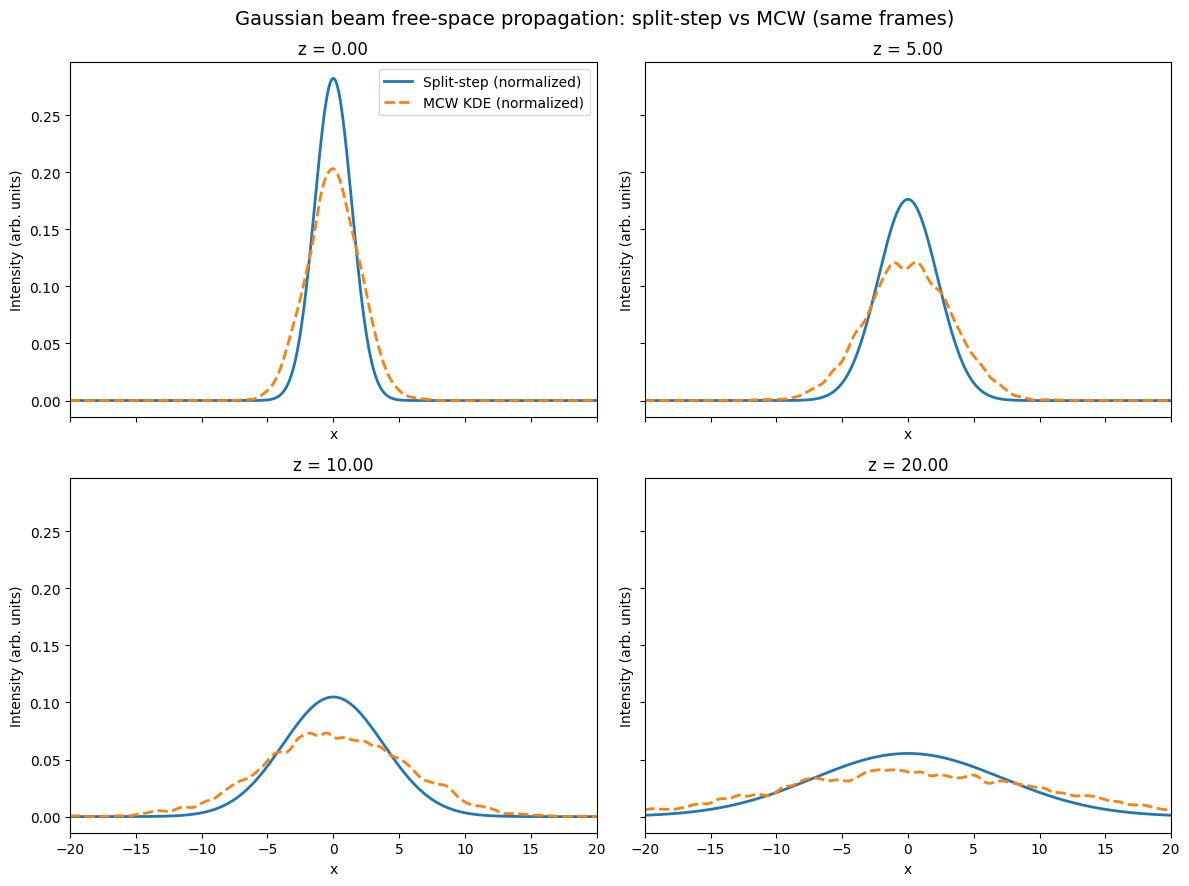

In [12]:
def demo_mcw_optics_gaussian_beam():
    """
    Demonstrate classical paraxial free-space propagation for a Gaussian beam
    using:
      (1) Split-step (free Schrödinger-like evolution with V=0).
      (2) MCW propagation in phase space (ballistic transport).
    """
    # We re-use the Schrödinger machinery with V=0,
    # interpreting t as propagation distance z.
    hbar = 1.0
    m = 1.0   # plays the role of k0 here

    # Spatial grid
    N = 2**12
    x_max = 40.0
    x = np.linspace(-x_max, x_max, N, endpoint=False)

    # Initial "beam" (Gaussian field)
    x0 = 0.0
    p0 = 0.0   # collimated beam (no initial tilt)
    sigma = 2.0
    psi0 = gaussian_wavepacket(x, x0=x0, p0=p0, sigma=sigma, hbar=hbar)

    # Free-space propagation: V(x) = 0
    V_zero = lambda xgrid: 0.0 * xgrid

    dz = 0.05
    nsteps = 400

    # Split-step evolution
    psi_z = split_operator_propagate(psi0, x, dz, nsteps, V_zero, m=m, hbar=hbar)
    n_frames = psi_z.shape[0]

    # Choose safe snapshot indices within [0, n_frames-1]
    indices = [
        0,
        n_frames // 4,
        n_frames // 2,
        n_frames - 1
    ]
    z_eval = [idx * dz for idx in indices]

    # MCW: sample initial Wigner of the Gaussian beam
    Np = 5000
    xs, ps, signs = sample_wigner_gaussian(
        Np,
        x0=x0,
        p0=p0,
        sigma=sigma,
        hbar=hbar,
    )

    # Propagate particles in z (classical Liouville)
    xs_final, ps_final = mcw_propagate_free_optics(
        xs, ps, dz, nsteps, m=m, x_max_abs=x_max
    )

    # Reconstruct MCW intensity at final z
    rho_m_final = wigner_to_position_density(xs_final, signs, x, bandwidth=0.4)

    # Plot snapshots of |U(x,z)|² from split-step
    # ---- Combined snapshots: split-step vs MCW (same frames) ----
    # Create MCW snapshots by propagating the same initial particle ensemble and
    # recording intermediate states so signs stay aligned with particles.
    xs0, ps0, signs0 = xs.copy(), ps.copy(), signs.copy()
    xs_t, ps_t, signs_t = xs0.copy(), ps0.copy(), signs0.copy()

    # Record particle positions/signs at selected indices
    mcw_snapshots = {}
    target_set = set(indices.tolist() if hasattr(indices, 'tolist') else list(indices))
    if 0 not in target_set:
        target_set.add(0)

    for step in range(max(target_set) + 1):
        if step in target_set:
            mcw_snapshots[step] = (xs_t.copy(), signs_t.copy())

        # advance one step (skip after last needed snapshot)
        if step == max(target_set):
            break

        xs_t = xs_t + dz * ps_t / m
        mask = np.abs(xs_t) < x_max
        xs_t, ps_t, signs_t = xs_t[mask], ps_t[mask], signs_t[mask]

    # Plot snapshots in a single multi-panel figure (like Part 2)
    nshots = len(indices)
    ncols = 2
    nrows = int(np.ceil(nshots / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(12, 4.5 * nrows), sharex=True, sharey=True)
    axes = np.atleast_1d(axes).ravel()

    for ax, z, idx in zip(axes, z_eval, indices):
        # Split-step intensity
        psi = psi_z[idx]
        rho_s = np.abs(psi)**2

        # MCW reconstructed intensity at same z
        xs_snap, signs_snap = mcw_snapshots[int(idx)]
        rho_m = wigner_to_position_density(xs_snap, signs_snap, x, bandwidth=0.4)

        # Normalize both to unit area for fair comparison
        area_s = np.trapz(rho_s, x)
        area_m = np.trapz(rho_m, x)
        if area_s > 0: rho_s = rho_s / area_s
        if area_m > 0: rho_m = rho_m / area_m

        ax.plot(x, rho_s, lw=2.0, label='Split-step (normalized)')
        ax.plot(x, rho_m, '--', lw=2.0, label='MCW KDE (normalized)')
        ax.set_title(f'z = {z:.2f}')
        ax.set_xlim(-20, 20)
        ax.set_xlabel('x')
        ax.set_ylabel('Intensity (arb. units)')

    # Hide any unused axes
    for j in range(len(indices), len(axes)):
        axes[j].axis('off')

    axes[0].legend(loc='best')
    fig.suptitle('Gaussian beam free-space propagation: split-step vs MCW (same frames)', y=0.98, fontsize=14)
    fig.tight_layout()
    plt.show()



demo_mcw_optics_gaussian_beam()


Optional: Uncomment the cell below to run this entire project.

In [13]:
# if __name__ == "__main__":
    # demo_mcw_vs_split_step()             # Part 1
    # demo_mcw_tunneling_double_well()   # Part 2 (uncomment to run)
    # demo_mcw_optics_gaussian_beam()    # Part 3 (uncomment to run)
